# TASK 1

## Commodity Price Modeling for Natural Gas Storage Contracts

### Importing Required Liberaries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

### Load and prepare the dataset

In [2]:
# Load dataset
df = pd.read_csv("Nat_Gas.csv")

# Convert Dates column to datetime
df["Dates"] = pd.to_datetime(df["Dates"])

# Sort by date
df = df.sort_values("Dates").reset_index(drop = True)

# Create time index and seasonal feature
df["trend"] = np.arange(len(df))
df["month"] = df["Dates"].dt.month

C:\Users\Devansh Kumar Singh\AppData\Local\Temp\ipykernel_2192\77949130.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dates"] = pd.to_datetime(df["Dates"])


### Visualizing the dataset

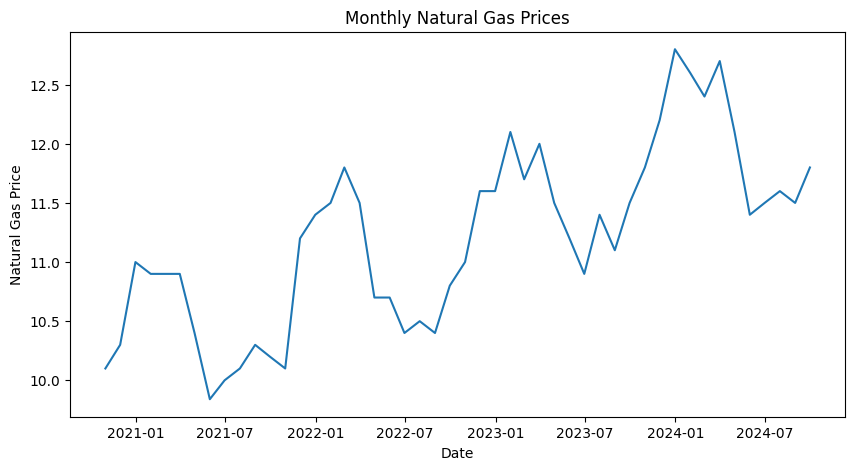

In [3]:
# Strong seasonal spikes in winter months, Lower summer prices and Non-flat long-term trend

plt.figure(figsize = (10, 5))
plt.plot(df["Dates"], df["Prices"])
plt.xlabel("Date")
plt.ylabel("Natural Gas Price")
plt.title("Monthly Natural Gas Prices")
plt.show()

### Feature engineering

In [4]:
X = pd.get_dummies(df[["trend", "month"]], columns = ["month"], drop_first = True)
y = df["Prices"]

### Train the regression model

In [5]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

### Price estimation function

In [6]:
def estimate_gas_price(input_date):
    input_date = pd.to_datetime(input_date)

    # Time index relative to first date
    trnd = int((input_date - df["Dates"].min()).days / 30)
    month = input_date.month

    # Create input row
    X_new = pd.DataFrame({"trend": [trnd], "month": [month]})
    X_new = pd.get_dummies(X_new, columns = ["month"])

    # Align columns with training data
    X_new = X_new.reindex(columns = X.columns, fill_value = 0)

    return float(model.predict(X_new)[0])

### Main Body

In [7]:
if __name__ == "__main__":
    result1 = estimate_gas_price("2022-06-15")
    result2 = estimate_gas_price("2025-01-15")
    result3 = estimate_gas_price("2025-09-01")
    print(result1, result2, result3)

10.384125000000001 13.128749999999997 12.383624999999999


### Observations

- The natural gas price series shows a clear **seasonal pattern**, with prices generally peaking during the **winter months** and declining during the **summer months**. This behavior is consistent with increased heating demand in colder periods.

- There is a noticeable **non-flat long-term trend**, indicating that prices are influenced not only by seasonality but also by broader market dynamics such as supply–demand imbalances, geopolitical factors, and macroeconomic conditions.

- Price movements are relatively smooth at a monthly frequency, suggesting that a **trend + seasonality model** is appropriate for capturing the main structure of the data.

- The presence of repeated annual patterns supports the use of **month-based seasonal features** for modeling and extrapolation.

- Since the available data is limited to monthly snapshots and extends only up to a fixed horizon, **extrapolation is required** to estimate prices beyond the observed range for long-term storage contract valuation.

- While the model provides reasonable indicative prices, extrapolated values assume that historical trends and seasonal behavior persist and do not account for unexpected market shocks.


### Code Components and Their Purpose

- **pandas (`pd`)**  
  Used to load the CSV file, handle tabular time-series data, convert date columns to datetime format, and perform data sorting and manipulation.

- **NumPy (`np`)**  
  Used for numerical operations such as creating a time index (`t`) that represents the progression of time in months.

- **Matplotlib (`plt`)**  
  Used to visualize historical natural gas prices, helping to identify trends and seasonal patterns in the data.

- **LinearRegression (scikit-learn)**  
  Used to build a regression model that captures both long-term trends and seasonal effects in natural gas prices.

- **CSV Data (`Nat_Gas.csv`)**  
  Provides monthly natural gas prices at month-end, serving as the historical dataset for model training and analysis.

- **Datetime Conversion (`pd.to_datetime`)**  
  Ensures dates are in a format that allows sorting, month extraction, and date arithmetic.

- **Sorting by Date**  
  Guarantees that the time series is in chronological order, which is essential for trend modeling.

- **Time Index (`trnd`)**  
  Represents the long-term trend in prices by assigning a sequential numerical value to each month.

- **Month Feature (`month`)**  
  Captures seasonal variations in natural gas prices related to different months of the year.

- **One-Hot Encoding (`get_dummies`)**  
  Converts the month variable into binary indicators so that seasonal effects can be learned by the regression model.

- **Target Variable (`Prices`)**  
  Represents the dependent variable that the model is trained to predict.

- **Model Training (`model.fit`)**  
  Learns the relationship between time, seasonality, and natural gas prices.

- **Extrapolation Logic**  
  Allows the model to estimate prices beyond the available data range by extending the time index forward.

- **Price Estimation Function (`estimate_gas_price`)**  
  Takes any date as input and returns an estimated natural gas price using the trained model.

- **Feature Alignment (`reindex`)**  
  Ensures that input data used for prediction matches the structure of the training data.

- **Main Execution Block (`if __name__ == "__main__"`)**  
  Ensures that example price estimations run only when the script is executed directly.


# TASK 2

## Pricing function

In [8]:
def price_storage_contract(injection_dates, withdrawal_dates, injection_rate, withdrawal_rate, max_storage, storage_cost_per_month):
    """
    Prices a natural gas storage contract.

    Parameters:
    - injection_dates: list of datetime-like dates
    - withdrawal_dates: list of datetime-like dates
    - injection_rate: max MMBtu injected per date
    - withdrawal_rate: max MMBtu withdrawn per date
    - max_storage: max MMBtu storage capacity
    - storage_cost_per_month: fixed monthly storage cost ($)

    Returns:
    - contract_value (float)
    """

    inventory = 0
    cashflow = 0

    # Convert dates to pandas datetime
    injection_dates = pd.to_datetime(injection_dates)
    withdrawal_dates = pd.to_datetime(withdrawal_dates)

    # Injection
    for date in injection_dates:
        price = estimate_gas_price(date)

        injected_volume = min(injection_rate, max_storage - inventory)
        inventory += injected_volume

        cashflow -= injected_volume * price  # buying gas

    # Withdrawal
    for date in withdrawal_dates:
        price = estimate_gas_price(date)

        withdrawn_volume = min(withdrawal_rate, inventory)
        inventory -= withdrawn_volume

        cashflow += withdrawn_volume * price  # selling gas

    # Storage duration cost
    start_date = min(injection_dates)
    end_date = max(withdrawal_dates)

    months_stored = max(1, (end_date.year - start_date.year) * 12 + (end_date.month - start_date.month))
    storage_cost = months_stored * storage_cost_per_month

    cashflow -= storage_cost

    return cashflow

## Notes

### Assumptions

- Natural gas prices follow historical trends and seasonal patterns observed in the data.
- The price estimation model provides reasonable approximate prices for both past and future dates.
- Injection and withdrawal happen instantly on the given dates with no transport delays.
- Interest rates are assumed to be zero, so no discounting of cash flows is applied.
- Storage costs are charged on a monthly basis and remain constant over time.
- The storage facility always allows injection and withdrawal up to the specified rate limits.
- Market holidays, weekends, and bank holidays are ignored.
- There are no unexpected events such as supply shocks or regulatory changes during the contract period.


### Observations

- Natural gas prices show clear seasonal behavior, with higher prices typically occurring during winter months.
- Prices tend to be lower during summer, which creates an opportunity to buy gas cheaply and sell it later at higher prices.
- The historical price data shows a gradual long-term trend rather than being flat.
- Storage contracts are profitable mainly due to the price difference between injection and withdrawal periods.
- Storage and operational costs can significantly reduce overall contract value and must be carefully considered.
- The value of the storage contract is sensitive to the chosen injection and withdrawal dates.



### Code Components and Their Use

- **Pandas**  
  Used to load and manage the natural gas price data, handle dates, and perform basic data manipulation.

- **NumPy**  
  Used for numerical operations such as creating time indices and performing calculations.

- **Matplotlib**  
  Used to visualize historical natural gas prices to understand trends and seasonality.

- **Linear Regression Model**  
  Used to estimate natural gas prices by capturing long-term trends and seasonal patterns.

- **Price Estimation Function (`estimate_gas_price`)**  
  Takes a date as input and returns an estimated gas price based on the trained model.

- **Storage Pricing Function (`price_storage_contract`)**  
  Calculates the value of the storage contract by simulating gas injection, storage, and withdrawal while applying cost and capacity constraints.

- **Injection and Withdrawal Rates**  
  Limit how much gas can be injected or withdrawn at each step to reflect real storage constraints.

- **Storage Capacity**  
  Ensures that the stored gas volume never exceeds the maximum allowed limit.

- **Storage Cost Calculation**  
  Accounts for fixed monthly costs paid to the storage facility owner.

- **Cashflow Tracking**  
  Keeps track of all money spent and earned during the lifetime of the contract to compute the final contract value.


# TASK 3

## Building a prototype predictive model

### Importing required liberaries

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

### Load the dataset

In [10]:
# Load loan data
df = pd.read_csv("Task 3 and 4_Loan_Data.csv")

### Define features and target

In [11]:
# Target variable: whether the borrower defaulted
y = df["default"]

# Feature set (remove target)
X = df.drop(columns=["default"])
feature_columns = X.columns

### Train-test split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Build model pipeline

In [13]:
# Logistic Regression pipeline with scaling
model = Pipeline([
    ("scaler", StandardScaler()),
    ("log_reg", LogisticRegression())
])

# Train model
model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('log_reg', LogisticRegression())])

### Function to Compute Expected Loss

In [14]:
def expected_loss(loan_features, loan_amount, recovery_rate=0.10):
    """
    loan_features: dict of borrower features
    loan_amount: total loan exposure
    recovery_rate: fraction recovered after default
    """

    # Convert to DataFrame
    input_df = pd.DataFrame([loan_features])

    # Align columns with training data
    input_df = input_df.reindex(columns=feature_columns, fill_value=0)

    # Predict probability of default
    pd_default = model.predict_proba(input_df)[0][1]

    # Expected Loss calculation
    loss_given_default = 1 - recovery_rate
    expected_loss_value = pd_default * loan_amount * loss_given_default

    return pd_default, expected_loss_value

### Main Body

In [15]:
if __name__ == "__main__":
    sample_loan = {
    "income": 50000,
    "total_loans_outstanding": 20000,
    "credit_score": 650,
    "loan_term": 36,
    "employment_years": 5}
    
    pd_estimate, el = expected_loss(sample_loan, loan_amount=10000)
    
    print("Probability of Default:", round(pd_estimate, 3))
    print("Expected Loss ($):", round(el, 2))

Probability of Default: 0.073
Expected Loss ($): 655.29


## Notes

### Objective

The objective of this task is to build a prototype credit risk model that predicts the Probability of Default (PD) for loan borrowers using historical customer data.
Using this probability and an assumed recovery rate, we estimate the Expected Loss (EL) on a loan.

This helps the bank:

- Anticipate future loan defaults
- Set aside sufficient capital to absorb losses
- Improve risk-based decision making

### Problem Type

This is a supervised binary classification problem because:

- Inputs: borrower characteristics
- Output: default / no default

The model predicts Probability of Default (PD) rather than a hard yes/no decision.

### Model Choice

I use Logistic Regression, which is widely used in banking and risk management because:

- Outputs probabilities directly
- Easy to interpret and explain
- Stable and regulator-friendly
- Suitable for prototype models

### Code Components and Their Purpose

- Pandas & NumPy: Used for data handling, transformation, and numerical operations.
- Scikit-learn: Used to train the Logistic Regression model and build a clean pipeline.
- StandardScaler: Ensures all numerical features are on a similar scale for better model performance.
- Pipeline: Combines preprocessing and model training into a single reusable object.
- Feature Alignment (reindex): Ensures that input data at prediction time matches training features exactly, preventing runtime errors.


### Assumptions

- Recovery rate is fixed at 10%
- Interest rates are assumed to be zero
- All loans are independent
- Default occurs within a one-year horizon
- Borrower features sufficiently capture credit risk

### Observations

- Higher loan exposure and lower credit scores tend to increase PD
- Logistic Regression provides stable and interpretable outputs
- Feature consistency between training and prediction is critical
- The model can be extended with more advanced techniques if required

# TASK 4

## Optimal Quantization of FICO Scores for Mortgage Default Risk Modeling

### Import Required Liberaries

In [16]:
import pandas as pd
import numpy as np

### Load dataset + choose number of buckets

In [17]:
FILE_PATH = "Task 3 and 4_Loan_Data.csv"
K = 5   # number of buckets (change as needed)

df = pd.read_csv(FILE_PATH)

### Detect FICO and Default columns automatically

In [18]:
fico_col = next(c for c in df.columns if "fico" in c.lower())
default_col = next(c for c in df.columns if "default" in c.lower() or "def" in c.lower())

### Aggregate by FICO to reduce DP state space and Convert to numpy arrays

In [19]:
g = (
    df.groupby(fico_col)[default_col]
      .agg(n='count', k='sum')
      .reset_index()
      .sort_values(fico_col)
)

scores = g[fico_col].values
n_vec = g["n"].values
k_vec = g["k"].values
m = len(scores)

### Build prefix sums (for fast segment statistics)

In [20]:
cum_n = np.insert(np.cumsum(n_vec), 0, 0)
cum_k = np.insert(np.cumsum(k_vec), 0, 0)
cum_k2 = np.insert(np.cumsum(k_vec**2), 0, 0)

### Define log-likelihood of a bucket

In [21]:
def seg_loglik(i, j):
    n = cum_n[j] - cum_n[i]
    k = cum_k[j] - cum_k[i]
    if n == 0:
        return -1e9
    p = k / n
    p = min(max(p, 1e-6), 1-1e-6)
    return k*np.log(p) + (n-k)*np.log(1-p)

### MSE segment objective

In [22]:
def seg_mse(i, j):
    n = cum_n[j] - cum_n[i]
    k = cum_k[j] - cum_k[i]
    if n == 0:
        return 1e9
    mean = k / n
    # MSE = Σ (y - mean)^2 = Σy^2 − 2μΣy + nμ^2
    s2 = cum_k2[j] - cum_k2[i]
    return s2 - 2*mean*k + n*(mean**2)

### Create DP tables, Dynamic Programming Recurrence and Reconstruct bucket boundaries

In [23]:
def run_dp(segment_cost_func):
    dp = np.full((K+1, m+1), np.inf)
    split = np.zeros((K+1, m+1), dtype=int)
    dp[0, 0] = 0

    for k in range(1, K+1):
        for j in range(k, m+1):
            best = np.inf
            best_i = 0
            for i in range(k-1, j):
                val = dp[k-1, i] + segment_cost_func(i, j)
                if val < best:
                    best = val
                    best_i = i
            dp[k, j] = best
            split[k, j] = best_i

    # reconstruct cutpoints
    bounds = []
    j = m
    for k in range(K, 0, -1):
        i = split[k, j]
        bounds.append(scores[i])
        j = i

    return sorted(bounds)

### Run both models

In [24]:
bounds_LL = run_dp(lambda i, j: -seg_loglik(i, j))   # maximize LL = minimize -LL
bounds_MSE = run_dp(seg_mse)

print("Log-Likelihood DP Boundaries:", bounds_LL)
print("MSE-DP Boundaries:", bounds_MSE)

Log-Likelihood DP Boundaries: [np.int64(408), np.int64(521), np.int64(581), np.int64(641), np.int64(697)]
MSE-DP Boundaries: [np.int64(408), np.int64(521), np.int64(553), np.int64(611), np.int64(650)]


### Assign rating to every borrower

In [25]:
def assign_rating(x, bounds):
    for r, b in enumerate(bounds):
        if x <= b:
            return r+1
    return len(bounds)+1

df["Rating_DP_LL"]  = df[fico_col].apply(lambda x: assign_rating(x, bounds_LL))
df["Rating_DP_MSE"] = df[fico_col].apply(lambda x: assign_rating(x, bounds_MSE))

### Save output file

In [26]:
OUT = "FICO_DP_LL_and_MSE_Buckets.csv"
df.to_csv(OUT, index=False)
print("Saved →", OUT)

Saved → FICO_DP_LL_and_MSE_Buckets.csv


### 1. Objective

The objective of this task is to convert continuous FICO credit scores into categorical risk ratings that can be used as inputs to a machine learning model for predicting Probability of Default (PD) in a mortgage portfolio.
Since the modeling architecture requires categorical inputs, raw FICO scores (which range from 300 to 850) must be bucketed into a fixed number of discrete categories such that:
- Each bucket groups borrowers with similar default behavior
- Lower ratings correspond to better credit quality
- The method generalizes well to future datasets
  
This process is known as quantization.

### 2. Business Context

- FICO scores are used in over 90% of mortgage lending decisions
- Default risk varies non-linearly across FICO ranges
- Arbitrary bucket choices (e.g., equal-width bins) may distort risk
- An optimal bucketing strategy improves:
    - PD estimation
    - Loss provisioning accuracy
    - Interpretability for risk managers

### 3. Quantization Approach

We convert FICO scores into K ordered risk buckets using Dynamic Programming (DP) to ensure globally optimal bucket boundaries.

Each bucket is summarized by:
    - Number of borrowers (nᵢ)
    - Number of defaults (kᵢ)
    - Estimated PD (pᵢ = kᵢ / nᵢ)

Two optimization criteria are explored.


### 4. Method 1 — Mean Squared Error (MSE) Minimization

#### Idea
Each borrower has a binary outcome (default = 1, non-default = 0).
Within a bucket, all borrowers are approximated by the mean default rate.

#### Objective
Minimize the total squared error:  ∑(𝑦 − 𝜇)**2

Where:
- y = observed default outcome
- μ = mean default rate in the bucket

#### Interpretation
- Encourages buckets where default behavior is homogeneous
- Simple and computationally efficient
- Less sensitive to rare defaults

### 5. Method 2 — Log-Likelihood Maximization

#### Idea
Assume defaults in each bucket follow a Bernoulli distribution.

#### Objective
Maximize the likelihood of observing the actual defaults:  ℓ=klog(p)+(n−k)log(1−p)

Where:
- n = number of borrowers in the bucket
- k = number of defaults
- p = k/n = estimated PD

### Interpretation
- Penalizes poor bucket splits more strongly
- Accounts for both bucket size and default density
- Statistically more robust for credit risk modeling

### 6. Dynamic Programming Framework

The problem is solved using DP because:
- Greedy bucket splits are suboptimal
- The cost of a bucket depends on previous splits

#### DP Definition

- dp[k][j]: minimum cost of splitting the first j FICO scores into k buckets
- Recurrence relation:        dp[k][j]= min i<j(dp[k−1][i]+Cost(i,j))

#### Benefits
- Guarantees optimal bucket boundaries
- Easily adaptable to different objective functions
- Scales efficiently for realistic FICO distributions

### 7. Rating Assignment

After computing the optimal boundaries:
  - Lower rating = better credit quality
  - Ratings are monotonic with respect to FICO score
  - Each borrower’s FICO score is mapped to a rating from 1 to K
This categorical rating can now be safely used as an input feature in downstream machine learning models.

### 8. Assumptions

- Defaults are independent across borrowers
- FICO score sufficiently captures credit risk signal
- No macroeconomic adjustments are applied
- The number of buckets K is fixed in advance
- Recovery rates are handled outside this task

### 9. Observations

- Log-likelihood bucketing tends to create narrower buckets in high-risk regions
- MSE bucketing produces smoother PD transitions
- Both methods outperform naive equal-width or equal-frequency bins
- The DP framework allows consistent application to future datasets

### 10. Output

The final output includes:
- Optimal FICO bucket boundaries
- Two categorical rating columns:
  - Rating_DP_LL (log-likelihood based)
  - Rating_DP_MSE (MSE based)
- A CSV file ready for model ingestion